In [12]:
import os

os.environ["PIPELINE_SCALE"] = "0.01"  # Limit OpenMP threads to avoid oversubscription

import pandas as pd
import data_lake as dl
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor



In [13]:
os.environ.get("PIPELINE_SCALE")

'0.01'

In [14]:
SEEDS = [42, 7, 13, 21, 101]
PARQUET_PATH = (dl.ROOT / "analysis_tables" / "full_table.parquet")

N_BOOT = 50
TARGET_COL = "ignition_probability_50"
TARGET_SCALE = 100
MIN_SLICE = 100
CORR_THRESHOLD = 0.8       # |r| at/above which features share a cluster
VIF_THRESHOLD = 5
ABLATION_CV = 5     
THRESHOLD_COL = "threshold_value"
LAYER = "werkschool"
         # folds for CV scores
RF_KWARGS = dict(
    n_estimators=100,
    max_depth=12,          # caps SHAP's depth² blowup
    min_samples_leaf=20,   # fewer, larger leaves → fewer paths to enumerate
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
)

OUTDIR = dl.ROOT / "analysis" / "topology_diffusion" / "rf_shap_analysis"  / LAYER / "topology_to_diffusion"

In [15]:
OUTDIR

WindowsPath('C:/Users/gulpenk/Documents/PhD projects/HPC/hpc_create_networks/data_lake_scale0.01/analysis/topology_diffusion/rf_shap_analysis/werkschool/topology_to_diffusion')

Loading CSV...
                                              network_id  threshold_idx  \
0                   sample_00109__lft_oplniv__werkschool              0   
3            sample_00029__etngrp_lft_oplniv__werkschool              0   
4                   sample_00284__etngrp_lft__werkschool              0   
7                          sample_00104__lft__werkschool              0   
9                     sample_00171__geslacht__werkschool              0   
...                                                  ...            ...   
13484  sample_00172__etngrp_geslacht_lft_oplniv__werk...              0   
13485                   sample_00140__oplniv__werkschool              0   
13489                 sample_00254__geslacht__werkschool              0   
13497  sample_00274__etngrp_geslacht_lft_oplniv__werk...              0   
13498      sample_00119__etngrp_geslacht_lft__werkschool              0   

       threshold_value  n_simulations  total_nodes  ignition_probability_50  \
0    

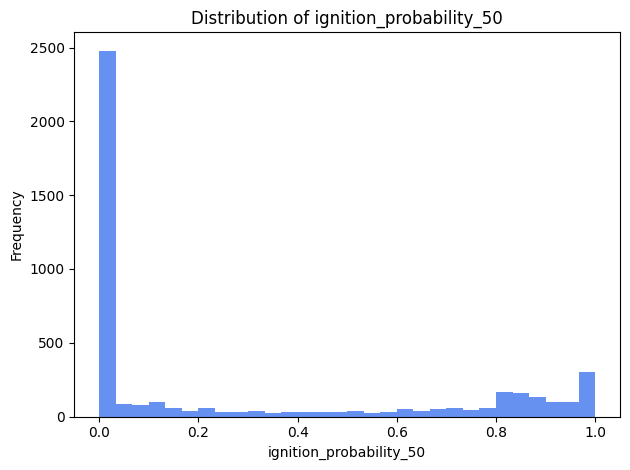

['pref_attachment', 'bridge_probability', 'approx_diameter', 'avg_local_clustering', 'avg_neighbor_degree_max', 'avg_neighbor_degree_mean', 'avg_neighbor_degree_median', 'avg_neighbor_degree_min', 'avg_neighbor_degree_q25', 'avg_neighbor_degree_q75', 'avg_neighbor_degree_skew', 'avg_neighbor_degree_std', 'coreness_max', 'coreness_mean', 'coreness_median', 'coreness_min', 'coreness_q25', 'coreness_q75', 'coreness_skew', 'coreness_std', 'density', 'detected_community_edges_inter_max', 'detected_community_edges_inter_mean', 'detected_community_edges_inter_median', 'detected_community_edges_inter_min', 'detected_community_edges_inter_q25', 'detected_community_edges_inter_q75', 'detected_community_edges_inter_skew', 'detected_community_edges_inter_std', 'detected_community_edges_intra_max', 'detected_community_edges_intra_mean', 'detected_community_edges_intra_median', 'detected_community_edges_intra_min', 'detected_community_edges_intra_q25', 'detected_community_edges_intra_q75', 'detected

,ignition_probability_50,threshold_value,pref_attachment,bridge_probability,approx_diameter,avg_local_clustering,avg_neighbor_degree_max,avg_neighbor_degree_mean,avg_neighbor_degree_median,avg_neighbor_degree_min,...,total_degree_max,total_degree_mean,total_degree_median,total_degree_min,total_degree_q25,total_degree_q75,total_degree_skew,total_degree_std,seed,random
0,0.85,0.3,0,0.0,11.0,0.450153,171.000000,89.897755,86.341774,2.00000,...,239.0,72.838958,66.0,1.0,46.0,94.0,0.738848,36.566312,42,3
3,0.10,0.3,0,0.0,9.0,0.434494,320.000000,101.688871,98.965517,1.00000,...,450.0,73.196858,60.0,1.0,36.0,97.0,1.647734,51.913107,42,2
4,0.00,0.3,0,0.0,17.0,0.614751,175.824324,83.499918,86.739130,1.00000,...,258.0,73.951392,73.0,1.0,36.0,106.0,0.288222,46.020258,42,4
7,0.89,0.3,0,0.0,20.0,0.580499,231.000000,101.802203,96.888889,2.00000,...,282.0,72.706203,62.0,1.0,39.0,95.0,1.017033,46.467472,42,1
9,0.00,0.3,0,0.0,71.0,0.846826,185.909091,83.533595,82.906250,2.00000,...,288.0,68.388028,64.0,2.0,36.0,92.0,1.018174,41.230456,42,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13484,0.00,0.3,0,0.0,13.0,0.743658,170.000000,78.035498,73.945946,1.00000,...,295.0,73.783335,71.0,1.0,50.0,96.0,0.290860,36.641339,42,1
13485,0.89,0.3,0,0.0,42.0,0.485538,138.833333,83.077811,82.298246,46.15625,...,190.0,68.276712,63.0,13.0,43.0,86.0,0.803064,30.560222,42,3
13489,0.00,0.3,0,0.0,114.0,0.853672,251.000000,90.318760,89.266667,2.00000,...,302.0,68.515692,60.0,1.0,38.0,90.0,1.534234,44.998003,42,3
13497,0.00,0.3,0,0.0,11.0,0.648378,210.000000,84.241745,83.260260,1.00000,...,281.0,74.071915,69.0,1.0,26.0,112.0,0.505333,53.445047,42,3


In [16]:
outdir = Path(OUTDIR)
outdir.mkdir(parents=True, exist_ok=True)

print("Loading CSV...")
df = pd.read_parquet(PARQUET_PATH)
# df1 = pd.read_parquet(PARQUET_PATH1)

# df = pd.concat([df1, df])
# df = df.loc[:, ~df.columns.duplicated()]
# df = df[df.optimize == 1]
if LAYER:
    df = df[df.network_id.str.contains(LAYER)]
print(df)
# df = df[df["network_id"].str.count("_") > 6]
plt.hist(df[TARGET_COL], bins=30, color="#2563eb", alpha=0.7)
plt.xlabel(f"{TARGET_COL}")
plt.ylabel("Frequency")
plt.title(f"Distribution of {TARGET_COL}")
plt.tight_layout(); plt.savefig(outdir / "target_distribution.png", dpi=130)
plt.show()



df["random"] = np.random.randint(1, 6, df.shape[0])
feats = []
for count, i in enumerate(df.columns):
    if count > 14 and not (
        "werkschool" in i or 
        "familie"  in i or 
        "huishouden"  in i or
        "assigned" in i or
        "mix_" in i or
        "transitivity" in i or
        "num_communities" in i or
        "reciprocity" in i or 
        "n_communities" in i or
        "refine_loss_goal" in i or
        "refine_loss" in i or 
        "density_by_degree" in i or
        "density_by_size" in i or
        "time" in i or
        "optimize" in i or
        "max_coreness" in i or
        "density_by_minsize" in i):

        feats.append(i)

print(feats)


keep = df[[TARGET_COL, THRESHOLD_COL] + feats].apply(pd.to_numeric,
                                                     errors="coerce").dropna()

# 2. See how many NAs are in each column
print("Nulls per column after coercion:")
print(keep.isna().sum().sort_values())

# 3. See how many rows you started with for context
print(f"\nTotal rows: {len(keep)}")

keep

In [ ]:
if LAYER == "werkschool": 
    # TARGET_COLS = ["coreness_std", "detected_community_edges_inter_skew", "coreness_mean"]
    TARGET_COLS = ["detected_community_edges_inter_skew", "coreness_q75", "detected_community_density_by_size_intra_std", "detected_community_edges_intra_skew", "ignition_probability_50"]
    # TARGET_COLS = ["ignition_probability_50"]
if LAYER == "buren":
    TARGET_COLS = ["detected_community_edges_inter_mean", "detected_community_n_observed", "detected_community_edges_inter_std", "detected_community_edges_inter_skew", "ignition_probability_50"]
    # TARGET_COLS = ["ignition_probability_50"]

In [18]:
model = RandomForestRegressor(**RF_KWARGS)

X = FEATURE_COLS
y = keep[TARGET_COL]

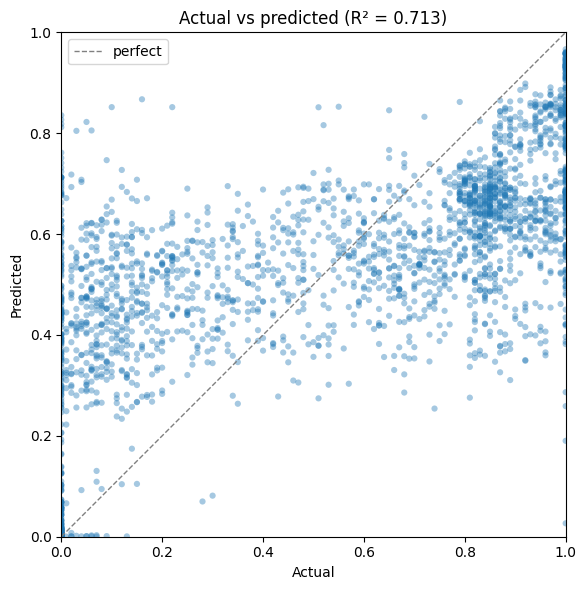

In [19]:
from sklearn.model_selection import cross_val_predict, KFold
import matplotlib.pyplot as plt
import numpy as np

model = RandomForestRegressor(**RF_KWARGS)

X = keep[FEATURE_COLS]
y = keep[TARGET_COL]

model.fit(X, y)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)

r2 = np.corrcoef(y, y_pred)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred, alpha=0.4, edgecolor="none", s=20)

lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, "--", color="gray", lw=1, label="perfect")

ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"Actual vs predicted (R² = {r2:.3f})")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
"""Lean SBM pipeline: generate -> stats -> ignition probability -> one-row df."""
import networkx as nx
import numpy as np
import pandas as pd
import igraph as ig
from scipy.stats import skew


def sbm(N=9000, n_comm=400, k=20, mu=0.1, seed=42):
    """SBM with <k> back-solved from target degree; mu = between-community edge fraction."""
    rng = np.random.default_rng(seed)
    sizes = [N // n_comm] * n_comm
    for i in rng.choice(n_comm, N - sum(sizes), replace=False):
        sizes[i] += 1
    avg = N / n_comm
    p = np.full((n_comm, n_comm), mu * k / (N - avg))
    np.fill_diagonal(p, (1 - mu) * k / (avg - 1))
    return nx.stochastic_block_model(sizes, p.tolist(), seed=seed)


def dist(x, prefix):
    return {f"{prefix}_mean": float(np.mean(x)), f"{prefix}_std": float(np.std(x)),
            f"{prefix}_skew": float(skew(x)) if len(x) > 2 else 0.0}


def stats(G_nx):
    """Node-level metrics + detected-community (label propagation) edge structure."""
    G = ig.Graph(n=G_nx.number_of_nodes(), edges=list(G_nx.edges()), directed=False)
    part = G.community_label_propagation()
    m = np.asarray(part.membership)
    _, sizes = np.unique(m, return_counts=True)
    k = len(sizes)

    edges = np.array(G.get_edgelist(), dtype=np.int64)
    e = np.zeros((k, k), dtype=np.int64)
    np.add.at(e, (m[edges[:, 0]], m[edges[:, 1]]), 1)

    core = np.asarray(G.coreness())
    clust = np.asarray(G.transitivity_local_undirected(mode="zero"))
    knn = np.asarray([v if v is not None else 0.0 for v in G.knn()[0]])

    inter, intra = ~np.eye(k, dtype=bool), np.eye(k, dtype=bool)
    return {"coreness_q75":            float(np.quantile(core, 0.75)),
            "global_clustering":       float(G.transitivity_undirected(mode="zero")),
            "avg_neighbor_degree_q25": float(np.quantile(knn, 0.25)),
            "local_clustering_min":    float(clust.min()),
            "modularity":              float(G.modularity(part)),
            "detected_community_n_observed": float(k),
            **dist(e[inter], "detected_community_edges_inter"),
            **dist(e[intra], "detected_community_edges_intra")}


def ignition(G, tau=0.09, cutoff=0.50, trials=200, k=30):
    """Fraction of focal-seed trials cascading past `cutoff` of the network."""
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    n = A.shape[0]
    deg = np.asarray(A.sum(1)).ravel()
    hubs = np.where(deg >= k)[0]
    print(len(hubs))
    hits = 0
    for t in range(trials):
        rng = np.random.default_rng(t)
        f = rng.choice(hubs)
        nb = A.indices[A.indptr[f]:A.indptr[f + 1]]
        state = np.zeros(n, dtype=bool)
        state[np.append(rng.choice(nb, k, replace=False), f)] = True
        while True:
            frac = np.divide(A @ state, deg, out=np.zeros(n), where=deg > 0)
            new = (~state) & (frac >= tau)
            if not new.any():
                break
            state[new] = True
        print(state.sum())
        hits += state.sum() / n > cutoff
    return hits / trials


def run(name="sbm_9000", **kw):
    G = sbm(**{p: kw[p] for p in ("N", "n_comm", "k", "mu", "seed") if p in kw})
    rec = stats(G)
    rec["ignition_probability"] = ignition(G)
    return pd.Series(rec, name=name).to_frame().T


if __name__ == "__main__":
    df = run()
    print(df.T.to_string())
    df.to_csv("sbm_pipeline_stats.csv")


def sweep(n_comm_values=None, N=9000, k=30, nc=300, mu=None, csv="sbm_sweep.csv"):
    """Run the pipeline across many SBMs (one per community count) -> stacked df."""
    if n_comm_values is None:
        n_comm_values = [10, 20, 30, 40, 50]
    if mu_values is None:
        mu_values = [0.1, 0.3, 0.5, 0.7, 0.9]
    rows = []

    for seed, ncom in enumerate(n_comm_values):
        for seed, mu in enumerate(mu_values):
            row = run(name=f"sbm_mu{mu}", N=N, n_comm=nc, k=k, mu=mu, seed=seed)
            row.insert(0, "mu", mu)
            rows.append(row)
            print(f"  mu={mu:4.1f}  detected={int(row['detected_community_n_observed'].iloc[0]):4d}"
                f"  ignition={row['ignition_probability'].iloc[0]:.3f}", flush=True)
    df = pd.concat(rows)
    df.to_csv(csv)
    return df

df = sweep()

1
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
140
                                       sbm_9000
coreness_q75                          16.000000
global_clustering                      0.670089
avg_neighbor_degree_q25               19.789474
local_

c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarni

4654
72
35
33
35
61
64
35
32
51
120
57
54
47
57
34
68
57
34
54
35
57
37
35
41
60
61
56
34
34
53
67
32
66
9000
37
69
64
61
39
35
62
65
66
36
39
58
60
55
35
66
67
56
39
37
37
34
59
62
33
60
73
63
60
40
39
59
59
63
32
35
56
31
32
33
63
109
38
59
53
34
41
39
36
62
66
36
60
61
33
64
35
36
35
53
57
57
36
49
38
59
35
35
42
57
59
71
32
34
53
59
54
34
34
54
55
56
62
32
39
73
57
57
35
34
34
56
31
52
36
57
54
61
64
38
9000
34
54
65
55
32
59
43
32
34
56
35
71
33
73
39
37
33
59
61
41
58
32
33
61
58
36
45
57
31
38
69
65
35
54
60
63
59
36
69
33
58
56
66
63
58
65
65
58
56
64
60
62
59
35
40
37
71
57
52
58
53
34
61
34
64
  mu= 0.8  detected=   1  ignition=0.010


c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\gulpenk\Documents\PhD projects\HPC\hpc_create_networks\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarni

4646
35
34
33
32
36
34
32
34
35
36
38
35
37
31
36
34
34
37
32
34
33
35
33
35
37
35
34
34
35
31
38
34
35
37
35
36
35
31
32
38
32
32
33
33
39
34
35
33
33
33
39
36
32
33
32
33
32
33
38
32
39
36
33
33
34
31
34
33
34
34
32
32
34
35
31
35
37
34
32
35
34
34
32
34
35
35
34
32
31
32
32
39
32
32
33
34
36
34
34
32
33
32
33
33
37
33
31
38
33
34
34
33
33
32
33
35
35
36
36
38
35
34
31
31
32
40
35
35
34
33
31
31
32
37
35
35
34
34
32
34
32
32
32
33
36
36
33
32
34
35
32
34
38
32
31
32
35
33
32
35
33
36
40
36
32
32
38
33
36
44
33
33
34
32
34
33
31
31
32
35
33
34
36
35
36
32
35
32
31
32
36
34
34
38
33
32
33
32
32
34
  mu= 0.9  detected=   1  ignition=0.000


In [62]:
print(df)

            mu  coreness_q75  global_clustering  avg_neighbor_degree_q25  \
sbm_mu0.1  0.1          25.0           0.748882                29.838710   
sbm_mu0.2  0.2          23.0           0.522853                29.800000   
sbm_mu0.3  0.3          22.0           0.350152                30.000000   
sbm_mu0.4  0.4          22.0           0.219011                30.121212   
sbm_mu0.5  0.5          22.0           0.128047                30.072735   
sbm_mu0.6  0.6          22.0           0.067402                30.218750   
sbm_mu0.7  0.7          22.0           0.029490                30.193548   
sbm_mu0.8  0.8          21.0           0.011024                30.166667   
sbm_mu0.9  0.9          21.0           0.004267                30.130435   

           local_clustering_min  modularity  detected_community_n_observed  \
sbm_mu0.1              0.407557    0.896697                          300.0   
sbm_mu0.2              0.242525    0.797165                          300.0   
sbm_m

In [65]:
df[FEATURE_COLS]

,detected_community_edges_inter_mean,detected_community_n_observed,detected_community_edges_inter_std,detected_community_edges_inter_skew
sbm_mu0.1,0.150401,300.0,0.416921,3.059820
sbm_mu0.2,0.299431,300.0,0.624942,2.352282
sbm_mu0.3,0.450647,300.0,0.807452,1.981308
sbm_mu0.4,0.604693,300.0,0.982397,1.766115
sbm_mu0.5,0.755830,299.0,1.171151,2.948946
sbm_mu0.6,0.931408,295.0,1.351338,1.546062
sbm_mu0.7,1.097281,294.0,1.524356,1.507093
sbm_mu0.8,NaN,1.0,NaN,0.000000
sbm_mu0.9,NaN,1.0,NaN,0.000000


In [64]:
print(model.predict(df[FEATURE_COLS]))

[0.30065461 0.30065461 0.30065461 0.30065461 0.30065461 0.30065461
 0.30065461 0.37823939 0.37823939]


<Axes: >

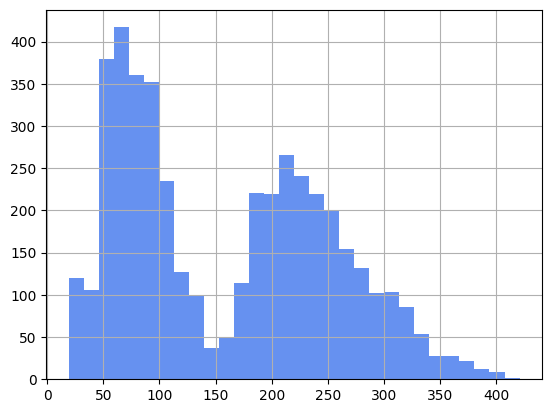

In [69]:
X["detected_community_n_observed"].hist(bins=30, color="#2563eb", alpha=0.7)

In [66]:
X

,detected_community_edges_inter_mean,detected_community_n_observed,detected_community_edges_inter_std,detected_community_edges_inter_skew
0,12.476660,71.0,57.248967,5.866160
3,11.448652,84.0,54.114589,9.320599
4,0.870493,238.0,9.147781,20.824221
7,8.933604,82.0,46.017049,6.103270
9,0.484573,304.0,8.615663,30.857085
...,...,...,...,...
13484,0.415452,238.0,2.756143,18.266974
13485,11.514337,63.0,60.619320,5.536212
13489,0.645113,284.0,10.553909,25.145670
13497,0.367449,337.0,3.380558,24.124631
